# MOSA Improvement Analysis — TabPFN Results

Comparison of **overlap + original** vs **expanded + mosa_all** to quantify the
maximum improvement from MOSA augmentation, using Pearson's r as the primary metric.

In [1]:
import json
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

REPORT_ROOT = pathlib.Path(
    "../reports/tabpfn/feature_augmentation/20260313_162348"
)

CONFIGS = {
    "overlap_original": ("overlap", "original"),
    "expanded_mosa_all": ("expanded", "mosa_all"),
}

TARGET_FAMILIES = ["drugresponse", "crisprcas9"]
FAMILY_LABELS = {"drugresponse": "Drug Response", "crisprcas9": "CRISPR"}

## 1. Load summary-level metrics

In [2]:
rows = []
for family in TARGET_FAMILIES:
    for label, (frame, variant) in CONFIGS.items():
        p = REPORT_ROOT / family / frame / variant / "test_metrics_summary.json"
        with open(p) as f:
            d = json.load(f)
        d["config"] = label
        d["family_label"] = FAMILY_LABELS[family]
        rows.append(d)

summary = pd.DataFrame(rows)
display(summary[
    ["family_label", "config", "train_n", "test_n",
     "test_pearsonr", "pooled_test_pearsonr", "test_rmse", "pooled_test_rmse"]
])

,family_label,config,train_n,test_n,test_pearsonr,pooled_test_pearsonr,test_rmse,pooled_test_rmse
0,Drug Response,overlap_original,95,24,0.220727,0.761900,0.175167,0.186695
1,Drug Response,expanded_mosa_all,231,24,0.323140,0.780367,0.168927,0.180751
2,CRISPR,overlap_original,95,24,0.143561,0.746732,0.659954,0.673153
3,CRISPR,expanded_mosa_all,132,24,0.213875,0.755426,0.649041,0.663021


## 2. Compute improvement (%) for Pearson's r

In [3]:
improvement_rows = []

for family in TARGET_FAMILIES:
    s = summary[summary["target_family"] == family]
    baseline = s[s["config"] == "overlap_original"].iloc[0]
    mosa = s[s["config"] == "expanded_mosa_all"].iloc[0]

    for metric in ["test_pearsonr", "pooled_test_pearsonr"]:
        base_val = baseline[metric]
        mosa_val = mosa[metric]
        abs_diff = mosa_val - base_val
        pct_change = (abs_diff / abs(base_val)) * 100
        improvement_rows.append({
            "Family": FAMILY_LABELS[family],
            "Metric": metric,
            "Overlap+Original": round(base_val, 4),
            "Expanded+MOSA_all": round(mosa_val, 4),
            "Abs. Diff": round(abs_diff, 4),
            "% Improvement": round(pct_change, 1),
        })

improvement_df = pd.DataFrame(improvement_rows)
display(improvement_df)

,Family,Metric,Overlap+Original,Expanded+MOSA_all,Abs. Diff,% Improvement
0,Drug Response,test_pearsonr,0.2207,0.3231,0.1024,46.4
1,Drug Response,pooled_test_pearsonr,0.7619,0.7804,0.0185,2.4
2,CRISPR,test_pearsonr,0.1436,0.2139,0.0703,49.0
3,CRISPR,pooled_test_pearsonr,0.7467,0.7554,0.0087,1.2


## 3. Load per-target Pearson's r

In [4]:
per_target = {}
for family in TARGET_FAMILIES:
    per_target[family] = {}
    for label, (frame, variant) in CONFIGS.items():
        p = REPORT_ROOT / family / frame / variant / "test_metrics_per_target.csv"
        per_target[family][label] = pd.read_csv(p)

for family in TARGET_FAMILIES:
    base = per_target[family]["overlap_original"]
    mosa = per_target[family]["expanded_mosa_all"]
    merged = base[["target", "test_pearsonr"]].merge(
        mosa[["target", "test_pearsonr"]],
        on="target", suffixes=("_base", "_mosa")
    )
    merged["delta"] = merged["test_pearsonr_mosa"] - merged["test_pearsonr_base"]
    per_target[family]["merged"] = merged
    print(f"\n{FAMILY_LABELS[family]}: {len(merged)} targets")
    print(f"  Targets improved:  {(merged['delta'] > 0).sum()}")
    print(f"  Targets worsened:  {(merged['delta'] < 0).sum()}")
    print(f"  Mean delta r:      {merged['delta'].mean():.4f}")
    print(f"  Median delta r:    {merged['delta'].median():.4f}")


Drug Response: 500 targets
  Targets improved:  363
  Targets worsened:  137
  Mean delta r:      0.1024
  Median delta r:    0.1081

CRISPR: 500 targets
  Targets improved:  329
  Targets worsened:  171
  Mean delta r:      0.0703
  Median delta r:    0.0807


## 4. Bar chart — Summary metrics comparison

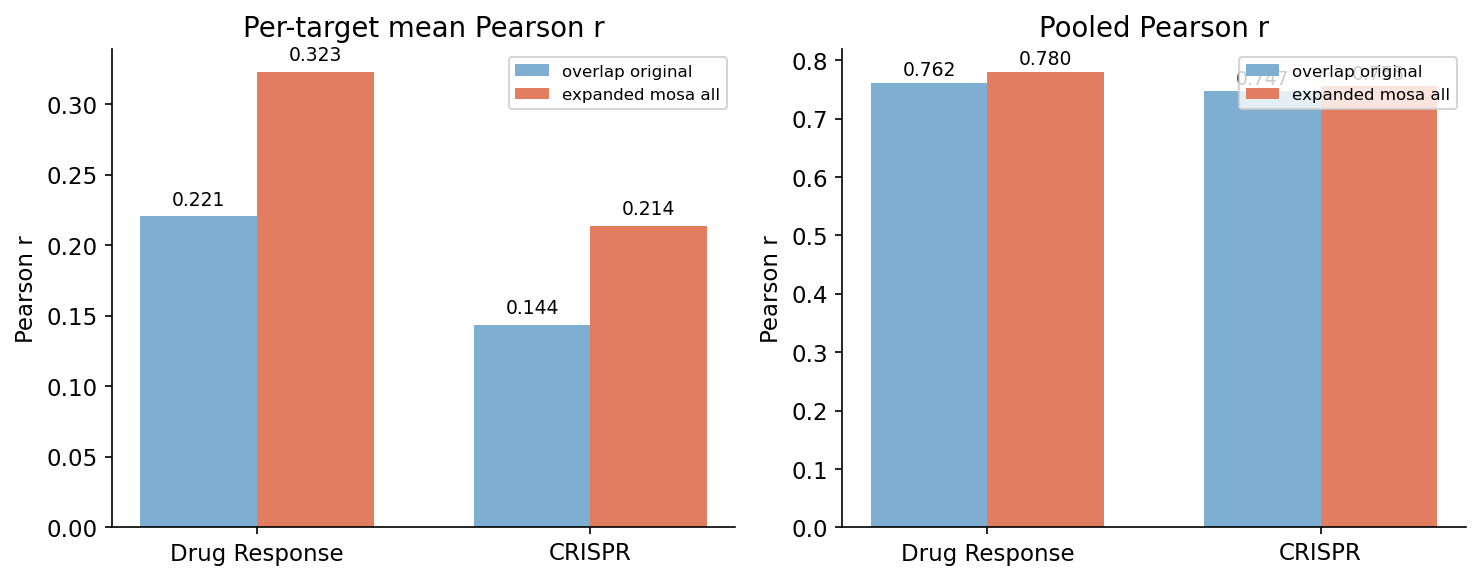

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

for ax, metric, title in zip(
    axes,
    ["test_pearsonr", "pooled_test_pearsonr"],
    ["Per-target mean Pearson r", "Pooled Pearson r"],
):
    x = np.arange(len(TARGET_FAMILIES))
    width = 0.35
    for i, (label, color) in enumerate(
        [("overlap_original", "#7eaed1"), ("expanded_mosa_all", "#e27d60")]
    ):
        vals = [
            summary[
                (summary["target_family"] == fam) & (summary["config"] == label)
            ][metric].values[0]
            for fam in TARGET_FAMILIES
        ]
        bars = ax.bar(x + (i - 0.5) * width, vals, width, label=label.replace("_", " "), color=color)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels([FAMILY_LABELS[f] for f in TARGET_FAMILIES])
    ax.set_ylabel("Pearson r")
    ax.set_title(title)
    ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

## 5. Per-target scatter — baseline vs MOSA

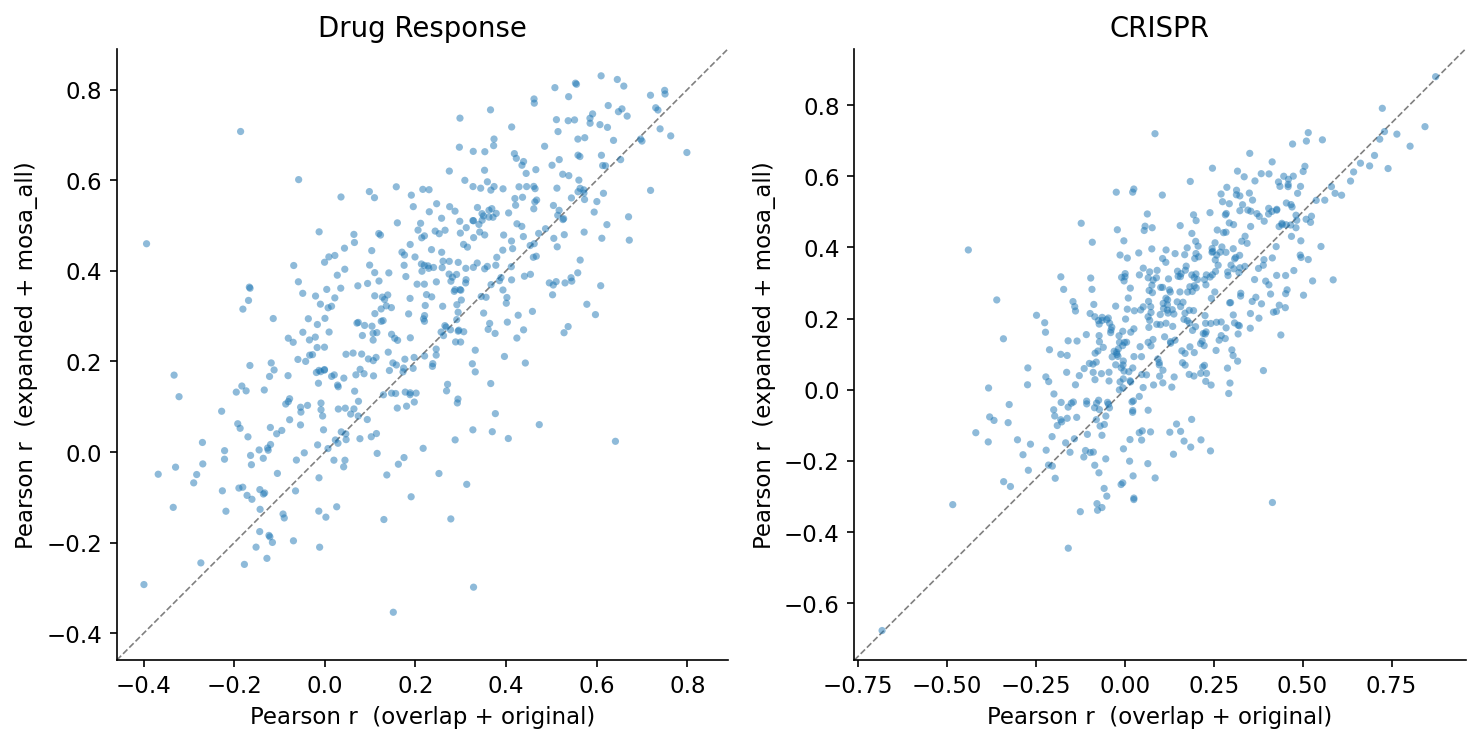

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, family in zip(axes, TARGET_FAMILIES):
    m = per_target[family]["merged"]
    ax.scatter(m["test_pearsonr_base"], m["test_pearsonr_mosa"],
               s=12, alpha=0.5, edgecolors="none")
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
            max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, "--", color="grey", linewidth=0.8, zorder=0)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel("Pearson r  (overlap + original)")
    ax.set_ylabel("Pearson r  (expanded + mosa_all)")
    ax.set_title(FAMILY_LABELS[family])
    ax.set_aspect("equal")

fig.tight_layout()
plt.show()

## 6. Histogram — per-target delta Pearson r

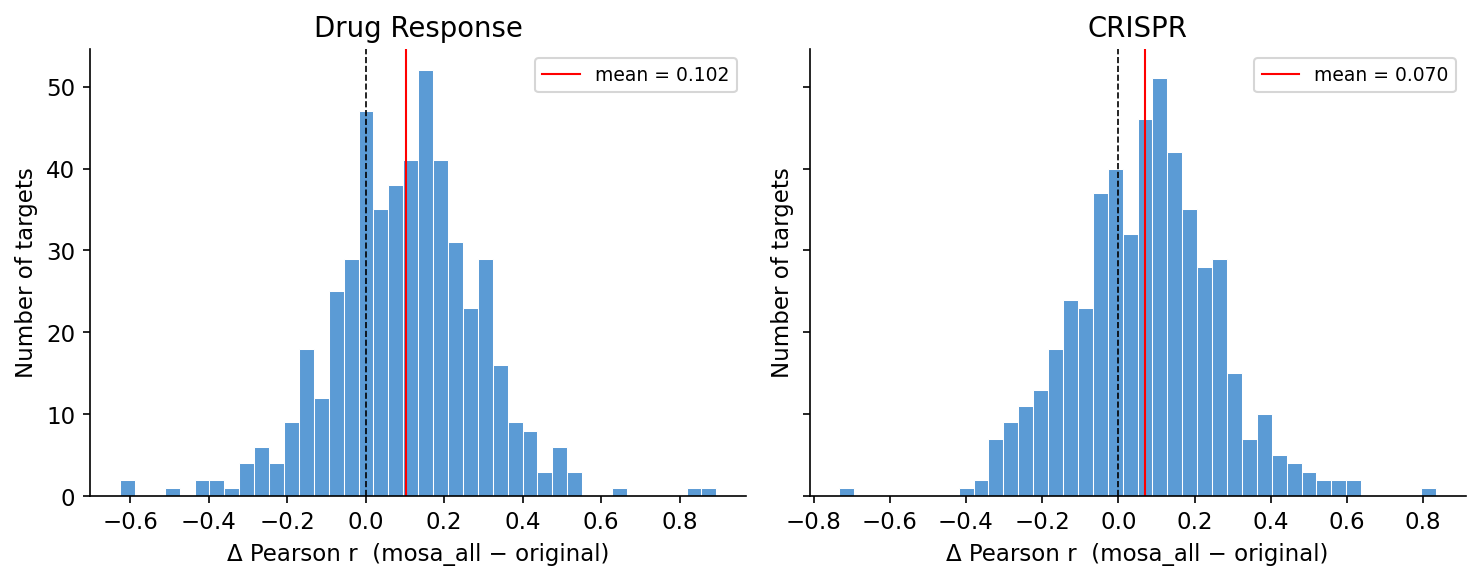

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, family in zip(axes, TARGET_FAMILIES):
    m = per_target[family]["merged"]
    ax.hist(m["delta"], bins=40, edgecolor="white", linewidth=0.5, color="#5b9bd5")
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.axvline(m["delta"].mean(), color="red", linewidth=1, linestyle="-",
               label=f"mean = {m['delta'].mean():.3f}")
    ax.set_xlabel("Δ Pearson r  (mosa_all − original)")
    ax.set_ylabel("Number of targets")
    ax.set_title(FAMILY_LABELS[family])
    ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

## 7. Key numbers for the abstract

In [8]:
print("=" * 60)
print("KEY NUMBERS FOR ABSTRACT")
print("=" * 60)

for family in TARGET_FAMILIES:
    s = summary[summary["target_family"] == family]
    base = s[s["config"] == "overlap_original"].iloc[0]
    mosa = s[s["config"] == "expanded_mosa_all"].iloc[0]

    label = FAMILY_LABELS[family]

    for metric, nice_name in [
        ("test_pearsonr", "Per-target mean Pearson r"),
        ("pooled_test_pearsonr", "Pooled Pearson r"),
    ]:
        b, m_val = base[metric], mosa[metric]
        pct = (m_val - b) / abs(b) * 100
        print(f"\n{label} — {nice_name}:")
        print(f"  Overlap+Original:   {b:.4f}")
        print(f"  Expanded+MOSA_all:  {m_val:.4f}")
        print(f"  Δ = {m_val - b:+.4f}  ({pct:+.1f}%)")

    m_merged = per_target[family]["merged"]
    frac_improved = (m_merged["delta"] > 0).mean() * 100
    print(f"\n  {label}: {frac_improved:.0f}% of targets improved (per-target r)")

print("\n" + "=" * 60)

KEY NUMBERS FOR ABSTRACT

Drug Response — Per-target mean Pearson r:
  Overlap+Original:   0.2207
  Expanded+MOSA_all:  0.3231
  Δ = +0.1024  (+46.4%)

Drug Response — Pooled Pearson r:
  Overlap+Original:   0.7619
  Expanded+MOSA_all:  0.7804
  Δ = +0.0185  (+2.4%)

  Drug Response: 73% of targets improved (per-target r)

CRISPR — Per-target mean Pearson r:
  Overlap+Original:   0.1436
  Expanded+MOSA_all:  0.2139
  Δ = +0.0703  (+49.0%)

CRISPR — Pooled Pearson r:
  Overlap+Original:   0.7467
  Expanded+MOSA_all:  0.7554
  Δ = +0.0087  (+1.2%)

  CRISPR: 66% of targets improved (per-target r)

